# Feature Sifting — step-size protected feature search

This notebook studies the **feature sifting** task (`phd/jax_core/tasks/feature_sifting.py`): an online
single-sample regression problem where the learner observes `n_learner_features` noisy candidate features,
each a noisy view of one of `n_target_features` true features. The target is a fixed weighted sum (weights
±1) of the true features. The learner predicts the target with a **linear model** and, each step, may mark
candidate slots for replacement (`prune_mask`); pruned slots are regenerated by the task with a fresh random
target index and noise coefficient. The learner must continually *sift* useful (low-noise) candidates from
useless ones.

Every method here uses the **Autostep** (IDBD) optimizer as its base learner, and differs only in *how it
decides to throw a feature away* (its generate-and-test rule). Each method is a self-contained `eqx.Module`
— read the class and you see the entire method.

### Methods compared
1. **Autostep** — Autostep online linear regression on a **fixed** candidate set (never prunes). The baseline
   with no feature search.
2. **Autostep + Generate & Test (Autostep + G&T)** — the simplest utility-based pruner: every `prune_period`
   steps, drop the single lowest-magnitude weight (utility = `|weight|`) and regenerate that slot. Like CBP,
   but the utility is just the weight magnitude and pruning is on a fixed clock.
3. **Autostep + G&T + step-size protection (median threshold)** — event-driven pruning. A feature becomes a
   prune candidate the step its Autostep gradient trace `h` flips sign; it is pruned only if its weight
   magnitude is in the **bottom half** of the current weights (`|w_i| < median |w|`).
4. **Autostep + G&T + step-size protection (non-zero-weight test)** — same `h`-flip trigger, but a feature is
   pruned only once it has *settled* (a per-feature clock `τ ≥ 3`) **and** its slow weight EMA `w̄` is
   statistically indistinguishable from zero: `|w̄_i| < k · sqrt(α_i · σ² / 2)`, where `σ²` is a running EMA
   of the squared prediction error (the noise power) and `k = 2.576` (≈ 99% normal quantile).

### How sweeping / caching works
Each method is run as an **mlflow-sweeper** grid sweep (programmatic `run_sweep`). Every configuration runs
`N` seeds batched in a single `jax.lax.scan` (jitted end-to-end) and logs the binned learning curve
(`loss`, `loss_std` = mean / std across seeds) plus a scalar `final_loss`. Because the sweeps and metrics
live in local MLflow/Optuna stores, **the experiments only run on the first execution** — re-running the
notebook finds the studies complete and just reloads the cached data.

In [1]:
import os
from dataclasses import dataclass

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import jax
import jax.numpy as jnp
import optax
import equinox as eqx
import mlflow
from omegaconf import OmegaConf

from mlflow_sweeper import SweepConfig, run_sweep, delete_sweep

from phd.jax_core.tasks.feature_sifting import FeatureSiftingTask
from phd.jax_core.optimizers.idbd import optax_idbd, IDBDState
from phd.jax_core.utils import tree_replace

from phd.research_utils.scripts.mlflow_download import download_experiment
from phd.research_utils.analysis.analysis_utils import (
    load_experiment_data, get_best_ablation_values, get_color_palette,
)

sns.set_theme('notebook', 'white')
%matplotlib inline

/home/edan/miniconda3/envs/jax/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configuration

Storage is kept in local files **relative to this notebook**, so the sweep state and logged metrics persist
across runs. Adjust `NUM_STEPS` / seed counts / grids below to trade off runtime vs. resolution.

In [2]:
EXPERIMENT = 'feature_sifting_protection'
NOTEBOOK_DIR = os.path.abspath('.')
DATA_DIR = os.path.join(NOTEBOOK_DIR, 'data')
SWEEP_OUTPUT_DIR = os.path.join(NOTEBOOK_DIR, 'sweep_output')
MLFLOW_URI = f"sqlite:///{os.path.join(NOTEBOOK_DIR, 'output', 'mlruns.db')}"
OPTUNA_URI = f"sqlite:///{os.path.join(NOTEBOOK_DIR, 'output', 'optuna.db')}"

os.environ['MLFLOW_TRACKING_URI'] = MLFLOW_URI
mlflow.set_tracking_uri(MLFLOW_URI)
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(SWEEP_OUTPUT_DIR, exist_ok=True)

# Task / training configuration.
N_TARGET_FEATURES = 10
N_LEARNER_FEATURES = 20
TARGET_NOISE_STD = 0.0
NUM_STEPS = 50_000
BASE_SEED = 0
N_SWEEP_SEEDS = 5       # seeds batched per sweep configuration
N_CURVE_SEEDS = 30      # seeds for the final best-config learning curves
N_LOG_POINTS = 250      # binned points logged per run (learning-curve resolution)
FINAL_FRACTION = 0.05   # last 5% of steps define the summary 'final loss'

# Loss of the trivial predictor (always predicts 0): E[y^2]. Each target weight is +-1
# and target features are uniform[-1, 1] (variance 1/3). Anything that learns beats this;
# anything that diverges exceeds it. Used as the convergence threshold for sensitivity plots.
BASELINE_LOSS = N_TARGET_FEATURES / 3.0 + TARGET_NOISE_STD ** 2

# Portion of the sweep config shared by every method.
BASE_SWEEP_CONFIG = {
    'experiment': EXPERIMENT,
    'optuna_storage': OPTUNA_URI,
    'mlflow_storage': MLFLOW_URI,
    'output_dir': SWEEP_OUTPUT_DIR,
    'algorithm': 'grid',
    'spec': {'direction': 'minimize', 'metric': 'final_loss'},
}
print('MLflow store :', MLFLOW_URI)
print('Baseline loss:', round(BASELINE_LOSS, 4))

MLflow store : sqlite:////home/edan/local_projects/phd_research/phd/sandbox/feature_sifting/exploration/output/mlruns.db
Baseline loss: 3.3333


## Core: the learner and shared primitives

A single linear layer `w` of shape `(1, n_learner_features)` predicts `y_hat = w · x` — the natural learner
for this task, and Autostep-compatible (2D weight, no bias). The loss is the squared prediction error on the
freshly observed sample.

**Method interface.** Each method (one per cell below) is an `eqx.Module` that bundles its own `init` and
`step`:

* `Method.init(hparams, key) -> Method` builds the Autostep optimizer, weights, and any algorithm state.
  Static hyperparameters (the optimizer, the prune period / constants) are `eqx.field(static=True)`; the
  dynamic state (weights, optimizer state, per-feature traces, …) are ordinary array fields.
* `method.step(x, y) -> (method, loss)` predicts, learns, and returns the updated module. It also carries a
  `prune_mask` field telling the task which candidate slots to regenerate next (all-`False` for methods that
  never recycle).

Only two things are shared across methods, and both are deliberately tiny so each method reads end-to-end on
its own: `linear_loss_and_grads` (the squared-error loss + gradient) and `reset_idbd_state` (put a pruned
slot's Autostep state back to initial, exactly as continual-backprop does when it recycles a feature).

In [3]:
def linear_loss_and_grads(w, x, y):
    """Squared-error loss of the linear prediction and its exact gradient wrt `w`."""
    y_hat = jnp.sum(w * x[None, :])
    error = y_hat - y
    return error ** 2, 2.0 * error * x[None, :]


def reset_idbd_state(opt_state, prune_mask):
    """Reset per-feature Autostep (IDBD) state for pruned / regenerated slots: step-size back
    to its initial value, and the gradient trace `h` and normaliser `v` to zero. `prune_mask` is
    a boolean array of shape (n_features,)."""
    m = prune_mask[None, :]   # broadcast over the single output row -> (1, n_features)
    return IDBDState(
        init_beta=opt_state.init_beta,
        beta=jnp.where(m, opt_state.init_beta, opt_state.beta),  # step-size -> initial
        h=jnp.where(m, 0.0, opt_state.h),
        v=jnp.where(m, 0.0, opt_state.v),
    )
def noise_floor(task):
    """Loss floor of the task's *current* feature set: for each of the ``n_target_features`` unique
    target features, the lowest noise coefficient among the candidate slots pointing at it (``1.0``
    for an uncovered target), summed. Lower-noise candidates covering more targets -> a lower floor,
    so this tracks the quality of the feature set a method has assembled."""
    target_idxs = jnp.arange(task.n_target_features)
    def min_noise_for_target(idx):
        points_here = task.learner_feature_idxs == idx
        return jnp.where(points_here.any(),
                         jnp.min(jnp.where(points_here, task.noise_coefficients, 1.0)),
                         1.0)
    return jnp.sum(jax.vmap(min_noise_for_target)(target_idxs))

## Sweep infrastructure

`MethodSpec` records a method's class, default hyperparameters, and label; each method registers itself in
`METHODS` from its own cell. `run_all_seeds` runs every seed of a config batched in a single jitted
`jax.lax.scan` — the loop only calls the module's `init` / `step` and routes `prune_mask` to the task.
`run_method_sweep` turns a grid into a programmatic mlflow-sweeper sweep (the objective fills in `defaults`
for any hyperparameter the grid does not sweep, and logs via `log_run`); `load_sweep_data` returns the
standard `config_dfs` / `run_dfs` dicts, downloading only when new runs have appeared.

In [4]:
import sys
if NOTEBOOK_DIR not in sys.path:           # make the sibling experiment_logging.py importable
    sys.path.insert(0, NOTEBOOK_DIR)
from experiment_logging import log_run, summarize_runs, plot_sensitivity, plot_learning_curve


@dataclass
class MethodSpec:
    name: str          # mlflow sweep_name
    label: str         # human-readable label for plots
    cls: type          # eqx.Module with .init(hparams, key) and .step(x, y) -> (module, loss)
    defaults: dict     # default hyperparameters; the grid overrides the subset it sweeps


METHODS = {}           # each method's cell below registers itself here


def swept_vars(grid):
    """The grid keys that actually vary (more than one value) — the swept hyperparameters."""
    return [k for k, vals in grid.items() if len(vals) > 1]


def run_all_seeds(method_cls, hparams, n_seeds):
    """Run `n_seeds` seeds (batched + jitted) of `method_cls` at `hparams`; losses (n_seeds, NUM_STEPS)."""
    def run_one_seed(seed_key):
        task_key, init_key = jax.random.split(seed_key)
        task = FeatureSiftingTask(N_TARGET_FEATURES, N_LEARNER_FEATURES, TARGET_NOISE_STD, key=task_key)
        state = method_cls.init(hparams, init_key)

        def scan_step(carry, _):
            task, state = carry
            task, (x, y) = task.step(state.prune_mask)     # task regenerates the recycled slots
            state, loss = state.step(x, jnp.squeeze(y))
            return (task, state), loss

        _, losses = jax.lax.scan(scan_step, (task, state), length=NUM_STEPS)
        return losses

    seed_keys = jax.random.split(jax.random.PRNGKey(BASE_SEED), n_seeds)
    return jax.jit(jax.vmap(run_one_seed))(seed_keys)


def make_objective(spec):
    def objective(**params):
        n_seeds = int(params.pop('n_seeds'))
        hparams = {**spec.defaults, **{k: float(v) for k, v in params.items()}}
        return log_run(run_all_seeds(spec.cls, hparams, n_seeds), N_LOG_POINTS, FINAL_FRACTION)
    return objective


def run_method_sweep(spec, grid, n_seeds, sweep_name=None, n_jobs=1, overwrite=False):
    sweep_name = sweep_name or spec.name
    params = dict(grid)
    params['n_seeds'] = int(n_seeds)
    cfg = {**BASE_SWEEP_CONFIG, 'sweep_name': sweep_name, 'parameters': params}
    config = SweepConfig.from_dict_config(OmegaConf.create(cfg))
    # End any lingering active run so re-running an already-complete sweep doesn't raise
    # "Run ... is already active".
    if mlflow.active_run() is not None:
        mlflow.end_run()

    if overwrite:
        delete_sweep(config)

    # allow_param_change updates the sweep in place when the config differs from the stored
    # one — e.g. after moving the MLflow/Optuna stores, or after editing a grid. Matching
    # trials are migrated (no recompute); only new/removed grid points actually run.
    run_sweep(config, make_objective(spec), n_jobs=n_jobs, log_params=True, no_plots=True,
              allow_param_change=True, executor='thread')


PARAMS_CSV = os.path.join(DATA_DIR, f'{EXPERIMENT}_params.csv')
METRICS_CSV = os.path.join(DATA_DIR, f'{EXPERIMENT}_metrics.csv')
RUN_COUNT_MARKER = os.path.join(DATA_DIR, f'.{EXPERIMENT}_run_count')


def _n_finished_runs():
    """Number of finished MLflow runs in the experiment (cheap; no metric history)."""
    client = mlflow.tracking.MlflowClient()
    exp = client.get_experiment_by_name(EXPERIMENT)
    if exp is None:
        return 0
    return len(client.search_runs([exp.experiment_id],
                                  filter_string="attributes.status = 'FINISHED'",
                                  max_results=50000))


def load_sweep_data(force_download=False):
    """Load the experiment's CSVs, downloading from MLflow only when needed.

    The download is skipped (cached CSVs are reloaded) whenever no new finished runs
    have appeared since the last download, so re-running analysis cells does not
    re-download. Pass ``force_download=True`` to force a fresh download.
    """
    n_runs = _n_finished_runs()
    have_csv = os.path.exists(PARAMS_CSV) and os.path.exists(METRICS_CSV)
    cached_n = int(open(RUN_COUNT_MARKER).read()) if os.path.exists(RUN_COUNT_MARKER) else -1
    if force_download or not have_csv or n_runs != cached_n:
        download_experiment(EXPERIMENT, output_dir=DATA_DIR, tracking_uri=MLFLOW_URI)
        with open(RUN_COUNT_MARKER, 'w') as f:
            f.write(str(n_runs))
    else:
        print(f'Reusing cached CSVs ({n_runs} runs, no new data to download).')
    return load_experiment_data(PARAMS_CSV, METRICS_CSV)


def best_hparams(cfgs, runs, spec, grid):
    """Best (min final-avg loss) hyperparameters for a method's grid sweep."""
    sv = swept_vars(grid)
    _, _, best = get_best_ablation_values(
        {spec.name: cfgs[spec.name]}, {spec.name: runs[spec.name]},
        sweep_ablation_vars={spec.name: sv},
        metric_col='loss', metric_direction='min', metric_type='final_avg',
        nan_policy='propagate', print_best_values=False,
    )
    return {key: float(val) for key, val in best[spec.name].items()}

## 1. Autostep

Autostep online linear regression on the **fixed** initial candidate set — no feature search. Sweeps the
initial step-size and the meta step-size.

In [5]:
class Autostep(eqx.Module):
    """Autostep (IDBD) online linear regression on a fixed candidate set; never recycles features."""
    optimizer: optax.GradientTransformation = eqx.field(static=True)
    w: jax.Array
    opt_state: optax.OptState
    prune_mask: jax.Array

    @classmethod
    def init(cls, hparams, key):
        n = N_LEARNER_FEATURES
        optimizer = optax_idbd(init_lr=hparams['learning_rate'],
                               meta_lr=hparams['meta_learning_rate'], autostep=True)
        w = jnp.zeros((1, n))
        return cls(optimizer=optimizer, w=w, opt_state=optimizer.init(w),
                   prune_mask=jnp.zeros(n, dtype=bool))

    def step(self, x, y):
        loss, loss_grads = linear_loss_and_grads(self.w, x, y)
        # Autostep/IDBD consumes both the loss gradient and the prediction gradient (= x).
        updates, opt_state = self.optimizer.update((loss_grads, x[None, :]), self.opt_state, self.w)
        w = optax.apply_updates(self.w, updates)
        return tree_replace(self, w=w, opt_state=opt_state), loss   # prune_mask stays all-False


AUTOSTEP_DEFAULTS = {'learning_rate': 2.0 ** -2, 'meta_learning_rate': 2.0 ** -4}
METHODS['autostep'] = MethodSpec('autostep', 'Autostep', Autostep, AUTOSTEP_DEFAULTS)

[I 2026-07-26 14:43:27,555] Using an existing study with name 'feature_sifting_protection/autostep' instead of creating a new one.
INFO:mlflow_sweeper.runner:Using existing parent MLflow run: 6f724617d7e749dc92f11ab2deb6d490.
INFO:mlflow_sweeper.runner:Study is complete. No more trials to run.


Reusing cached CSVs (138 runs, no new data to download).


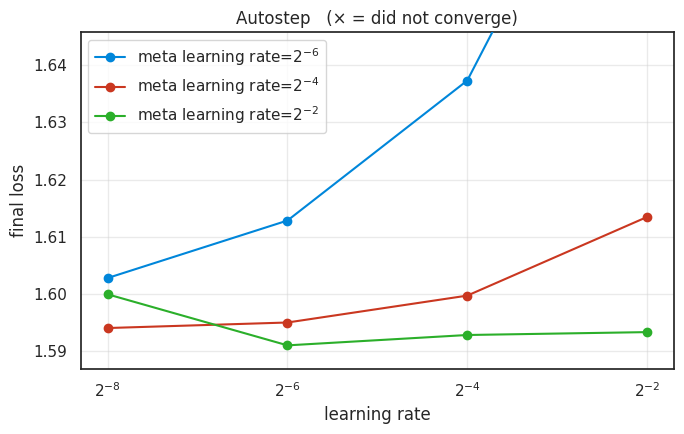

In [6]:
AUTOSTEP_GRID = {
    'learning_rate': [2.0 ** e for e in range(-8, -1, 2)],       # 2^-8 .. 2^-2  (initial step-size)
    'meta_learning_rate': [2.0 ** e for e in range(-6, -1, 2)],  # 2^-6 .. 2^-2
}
run_method_sweep(METHODS['autostep'], AUTOSTEP_GRID, N_SWEEP_SEEDS)
cfgs, runs = load_sweep_data()
autostep_summary = summarize_runs(cfgs, runs, 'autostep', swept_vars(AUTOSTEP_GRID), FINAL_FRACTION, BASELINE_LOSS)
plot_sensitivity(autostep_summary, swept_vars(AUTOSTEP_GRID), 'Autostep')
plt.show()

### Autostep — best configuration learning curve (30 seeds)

[I 2026-07-26 14:43:28,445] Using an existing study with name 'feature_sifting_protection/autostep_best' instead of creating a new one.
INFO:mlflow_sweeper.runner:Using existing parent MLflow run: e5d1ddd90a334ed1be6f1b579f60d1dd.
INFO:mlflow_sweeper.runner:Study is complete. No more trials to run.


Autostep best: {'learning_rate': 0.015625, 'meta_learning_rate': 0.25}
Reusing cached CSVs (138 runs, no new data to download).


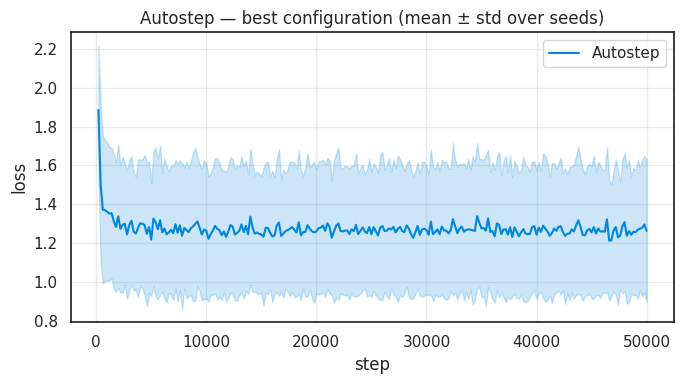

In [7]:
autostep_best = best_hparams(cfgs, runs, METHODS['autostep'], AUTOSTEP_GRID)
print('Autostep best:', autostep_best)
run_method_sweep(METHODS['autostep'], autostep_best, N_CURVE_SEEDS, sweep_name='autostep_best')
cfgs, runs = load_sweep_data()

plt.figure(figsize=(7, 4))
plot_learning_curve(runs, 'autostep_best', label='Autostep', color=get_color_palette(n=4)[0])
plt.title('Autostep — best configuration (mean ± std over seeds)')
plt.legend(); plt.tight_layout(); plt.show()

## 2. Autostep + Generate & Test

The simplest generate-and-test rule: every `prune_period` steps, drop the single lowest-magnitude weight
(utility = `|weight|`) and regenerate that slot. Like CBP, but the utility is just the weight magnitude and
pruning fires on a fixed clock rather than a replacement-rate accumulator. Sweeps step-size, meta step-size,
and the prune period.

In [8]:
class AutostepGT(eqx.Module):
    """Autostep + Generate & Test. Every `prune_period` steps, prune the single lowest-magnitude
    weight (utility = |weight|); the pruned slot is regenerated by the task and its Autostep state
    is reset to initial."""
    optimizer: optax.GradientTransformation = eqx.field(static=True)
    prune_period: int = eqx.field(static=True)
    w: jax.Array
    opt_state: optax.OptState
    step_idx: jax.Array
    prune_mask: jax.Array

    @classmethod
    def init(cls, hparams, key):
        n = N_LEARNER_FEATURES
        optimizer = optax_idbd(init_lr=hparams['learning_rate'],
                               meta_lr=hparams['meta_learning_rate'], autostep=True)
        w = jnp.zeros((1, n))
        return cls(optimizer=optimizer, prune_period=int(hparams['prune_period']),
                   w=w, opt_state=optimizer.init(w), step_idx=jnp.array(0),
                   prune_mask=jnp.zeros(n, dtype=bool))

    def step(self, x, y):
        loss, loss_grads = linear_loss_and_grads(self.w, x, y)
        updates, opt_state = self.optimizer.update((loss_grads, x[None, :]), self.opt_state, self.w)
        w = optax.apply_updates(self.w, updates)

        # Every `prune_period` steps, prune the single lowest-magnitude weight.
        step_idx = self.step_idx + 1
        should_prune = (step_idx % self.prune_period) == 0
        utility = jnp.abs(w[0])
        prune_mask = should_prune & (jnp.arange(w.shape[1]) == jnp.argmin(utility))
        w = jnp.where(prune_mask[None, :], 0.0, w)
        opt_state = reset_idbd_state(opt_state, prune_mask)

        return tree_replace(self, w=w, opt_state=opt_state, step_idx=step_idx,
                            prune_mask=prune_mask), loss


AUTOSTEP_GT_DEFAULTS = {'learning_rate': 2.0 ** -2, 'meta_learning_rate': 2.0 ** -4,
                        'prune_period': 2 ** 10}
METHODS['autostep_gt'] = MethodSpec('autostep_gt', 'Autostep + G&T', AutostepGT, AUTOSTEP_GT_DEFAULTS)

[I 2026-07-26 14:43:28,815] Using an existing study with name 'feature_sifting_protection/autostep_gt' instead of creating a new one.
INFO:mlflow_sweeper.runner:Using existing parent MLflow run: cb8b849b13534a7aae74aa11fe052d8c.


INFO:mlflow_sweeper.runner:Study is complete. No more trials to run.


Reusing cached CSVs (138 runs, no new data to download).


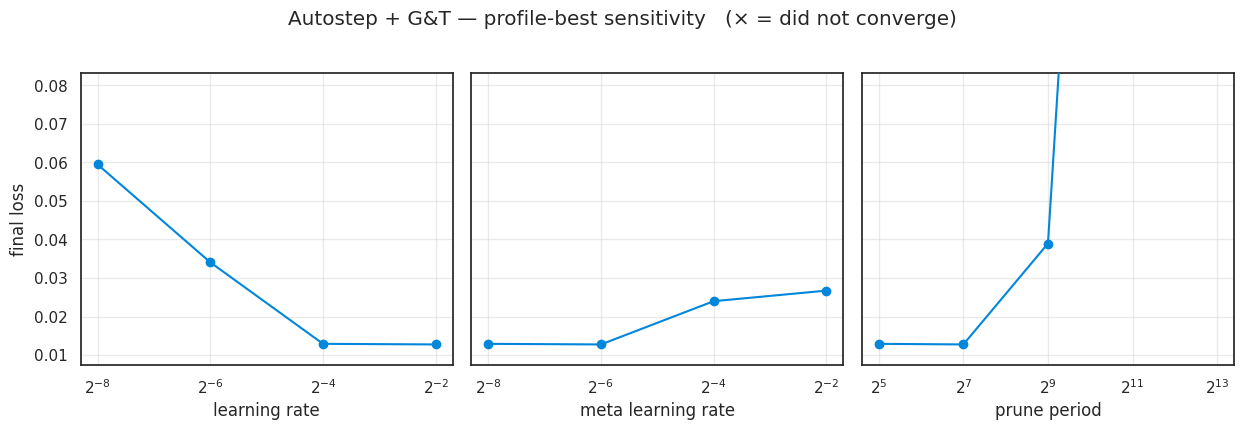

In [9]:
AUTOSTEP_GT_GRID = {
    'learning_rate': [2.0 ** e for e in range(-8, -1, 2)],       # 2^-8 .. 2^-2
    'meta_learning_rate': [2.0 ** e for e in range(-8, -3, 2)],  # 2^-6 .. 2^-2
    'prune_period': [2 ** 5, 2 ** 7, 2 ** 9, 2 ** 11],
}
run_method_sweep(METHODS['autostep_gt'], AUTOSTEP_GT_GRID, N_SWEEP_SEEDS)
cfgs, runs = load_sweep_data()
autostep_gt_summary = summarize_runs(cfgs, runs, 'autostep_gt', swept_vars(AUTOSTEP_GT_GRID), FINAL_FRACTION, BASELINE_LOSS)
plot_sensitivity(autostep_gt_summary, swept_vars(AUTOSTEP_GT_GRID), 'Autostep + G&T')
plt.show()

### Autostep + G&T — best configuration learning curve (30 seeds)

[I 2026-07-26 14:43:29,339] Using an existing study with name 'feature_sifting_protection/autostep_gt_best' instead of creating a new one.
INFO:mlflow_sweeper.runner:Using existing parent MLflow run: 6a038b7fe5464a9194371615ebbe49de.
INFO:mlflow_sweeper.runner:Study is complete. No more trials to run.


Autostep + G&T best: {'learning_rate': 0.25, 'meta_learning_rate': 0.015625, 'prune_period': 128.0}
Reusing cached CSVs (138 runs, no new data to download).


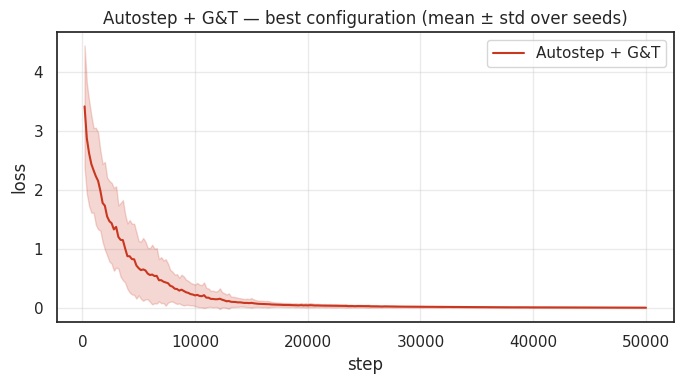

In [10]:
autostep_gt_best = best_hparams(cfgs, runs, METHODS['autostep_gt'], AUTOSTEP_GT_GRID)
print('Autostep + G&T best:', autostep_gt_best)
run_method_sweep(METHODS['autostep_gt'], autostep_gt_best, N_CURVE_SEEDS, sweep_name='autostep_gt_best')
cfgs, runs = load_sweep_data()

plt.figure(figsize=(7, 4))
plot_learning_curve(runs, 'autostep_gt_best', label='Autostep + G&T', color=get_color_palette(n=4)[1])
plt.title('Autostep + G&T — best configuration (mean ± std over seeds)')
plt.legend(); plt.tight_layout(); plt.show()

## 3. Autostep + G&T + step-size protection (median threshold)

Event-driven pruning instead of a fixed clock. Autostep's per-feature gradient trace `h` flipping sign is
the classic signal that a step-size overshot — a natural "test" event. When `h_i` flips sign this step, the
feature is pruned **only if** its weight magnitude is in the bottom half of the current weights
(`|w_i| < median |w|`), so a large, clearly-useful weight is never thrown away just for wobbling. Sweeps the
initial step-size and the meta step-size.

In [11]:
class AutostepMedianProtect(eqx.Module):
    """Autostep + G&T with median-threshold step-size protection. A feature is pruned the step its
    Autostep gradient trace `h` flips sign, but only if its weight magnitude is in the bottom half of
    the current weights (|w_i| < median |w|)."""
    optimizer: optax.GradientTransformation = eqx.field(static=True)
    w: jax.Array
    opt_state: optax.OptState
    prune_mask: jax.Array

    @classmethod
    def init(cls, hparams, key):
        n = N_LEARNER_FEATURES
        optimizer = optax_idbd(init_lr=hparams['learning_rate'],
                               meta_lr=hparams['meta_learning_rate'], autostep=True)
        w = jnp.zeros((1, n))
        return cls(optimizer=optimizer, w=w, opt_state=optimizer.init(w),
                   prune_mask=jnp.zeros(n, dtype=bool))

    def step(self, x, y):
        loss, loss_grads = linear_loss_and_grads(self.w, x, y)
        h_prev = self.opt_state.h
        updates, opt_state = self.optimizer.update((loss_grads, x[None, :]), self.opt_state, self.w)
        w = optax.apply_updates(self.w, updates)

        # Prune features whose h flipped sign this step AND whose |weight| is in the bottom half.
        flipped = (h_prev * opt_state.h < 0.0)[0]        # (n,)
        util = jnp.abs(w[0])                             # (n,)
        prune_mask = flipped & (util < jnp.median(util))
        w = jnp.where(prune_mask[None, :], 0.0, w)
        opt_state = reset_idbd_state(opt_state, prune_mask)

        return tree_replace(self, w=w, opt_state=opt_state, prune_mask=prune_mask), loss


AUTOSTEP_MEDIAN_DEFAULTS = {'learning_rate': 2.0 ** -2, 'meta_learning_rate': 2.0 ** -4}
METHODS['autostep_median'] = MethodSpec('autostep_median', 'Autostep + G&T + protection (median)',
                                        AutostepMedianProtect, AUTOSTEP_MEDIAN_DEFAULTS)

[I 2026-07-26 14:43:29,875] Using an existing study with name 'feature_sifting_protection/autostep_median' instead of creating a new one.
INFO:mlflow_sweeper.runner:Using existing parent MLflow run: 11eafbe655b143038367c1e297e20ab6.
INFO:mlflow_sweeper.runner:Study is complete. No more trials to run.


Reusing cached CSVs (138 runs, no new data to download).


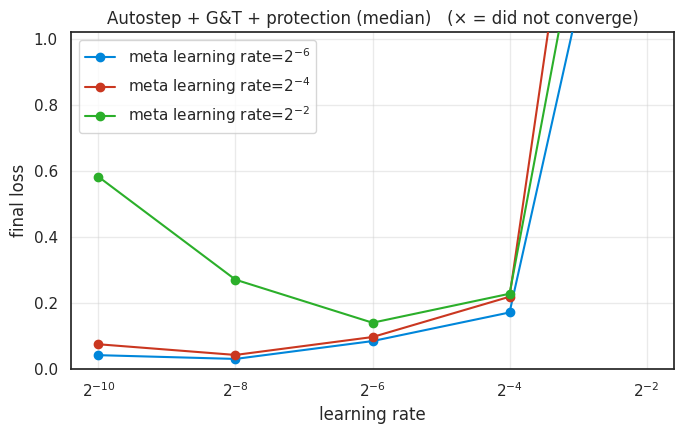

In [12]:
AUTOSTEP_MEDIAN_GRID = {
    'learning_rate': [2.0 ** e for e in range(-10, -3, 2)],       # 2^-8 .. 2^-2
    'meta_learning_rate': [2.0 ** e for e in range(-6, -1, 2)],  # 2^-6 .. 2^-2
}
run_method_sweep(METHODS['autostep_median'], AUTOSTEP_MEDIAN_GRID, N_SWEEP_SEEDS)
cfgs, runs = load_sweep_data()
autostep_median_summary = summarize_runs(cfgs, runs, 'autostep_median', swept_vars(AUTOSTEP_MEDIAN_GRID), FINAL_FRACTION, BASELINE_LOSS)
plot_sensitivity(autostep_median_summary, swept_vars(AUTOSTEP_MEDIAN_GRID), 'Autostep + G&T + protection (median)')
plt.show()

### Median-threshold protection — best configuration learning curve (30 seeds)

[I 2026-07-26 14:43:30,246] Using an existing study with name 'feature_sifting_protection/autostep_median_best' instead of creating a new one.
INFO:mlflow_sweeper.runner:Using existing parent MLflow run: 5a52d9f4a6c640da93252921923930f5.
INFO:mlflow_sweeper.runner:Study is complete. No more trials to run.


Autostep + G&T + protection (median) best: {'learning_rate': 0.00390625, 'meta_learning_rate': 0.015625}
Reusing cached CSVs (138 runs, no new data to download).


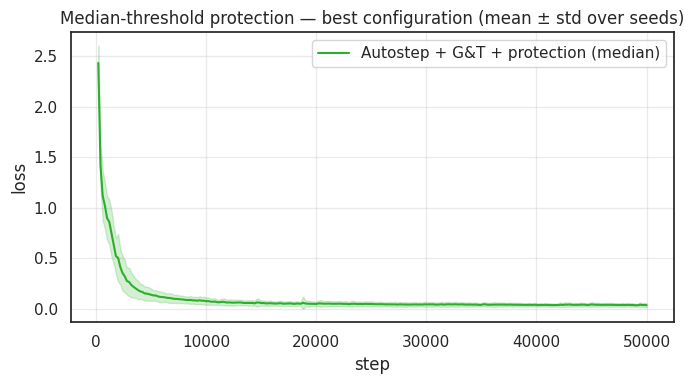

In [13]:
autostep_median_best = best_hparams(cfgs, runs, METHODS['autostep_median'], AUTOSTEP_MEDIAN_GRID)
print('Autostep + G&T + protection (median) best:', autostep_median_best)
run_method_sweep(METHODS['autostep_median'], autostep_median_best, N_CURVE_SEEDS, sweep_name='autostep_median_best')
cfgs, runs = load_sweep_data()

plt.figure(figsize=(7, 4))
plot_learning_curve(runs, 'autostep_median_best', label='Autostep + G&T + protection (median)',
                    color=get_color_palette(n=4)[2])
plt.title('Median-threshold protection — best configuration (mean ± std over seeds)')
plt.legend(); plt.tight_layout(); plt.show()

## 4. Autostep + G&T + step-size protection (non-zero-weight test)

Same `h`-flip trigger, but with a statistical test that only prunes a feature once we are confident its true
weight is zero. Per feature we track a **slow weight EMA** `w̄` and an **accumulated clock** `τ`, both stepped
at the feature's own step-size slowed by `c` (so faster-learning features settle sooner). Globally, `σ²` is an
EMA of the squared prediction error (the noise power), its rate slaved to the mean step-size. On an `h` sign
flip, once the feature has settled (`τ ≥ 3`), it is pruned only if `|w̄_i| < k · sqrt(α_i · σ² / 2)` — i.e. its
smoothed weight is within the noise band expected of a truly-zero weight. Constants `k = 2.576` (≈ 99% normal
quantile) and `c = 10`. Sweeps the initial step-size and the meta step-size.

In [14]:
class AutostepNonzeroProtect(eqx.Module):
    """Autostep + G&T with non-zero-weight step-size protection. A feature is pruned the step its
    Autostep trace `h` flips sign, once it has settled (clock tau >= 3) AND its slow weight EMA wbar
    is statistically indistinguishable from zero: |wbar_i| < k * sqrt(alpha_i * sig2 / 2), where sig2
    is an EMA of the squared prediction error."""
    optimizer: optax.GradientTransformation = eqx.field(static=True)
    c: float = eqx.field(static=True)   # clock slow-down (weight-average time constant)
    k: float = eqx.field(static=True)   # confidence multiplier (2.576 ~ 99% normal quantile)
    w: jax.Array
    opt_state: optax.OptState
    wbar: jax.Array     # slow EMA of each weight            (init 0)
    tau: jax.Array      # accumulated per-feature clock       (init 0)
    sig2: jax.Array     # EMA of the squared error (noise power, init 0)
    prune_mask: jax.Array

    @classmethod
    def init(cls, hparams, key):
        n = N_LEARNER_FEATURES
        optimizer = optax_idbd(init_lr=hparams['learning_rate'],
                               meta_lr=hparams['meta_learning_rate'], autostep=True)
        w = jnp.zeros((1, n))
        return cls(optimizer=optimizer, c=hparams['clock_c'], k=hparams['confidence_k'],
                   w=w, opt_state=optimizer.init(w), wbar=jnp.zeros(n), tau=jnp.zeros(n),
                   sig2=jnp.array(0.0), prune_mask=jnp.zeros(n, dtype=bool))

    def step(self, x, y):
        # loss = (pred - y)^2 = delta^2, so `loss` is exactly the delta^2 the noise EMA needs.
        loss, loss_grads = linear_loss_and_grads(self.w, x, y)
        h_prev = self.opt_state.h
        updates, opt_state = self.optimizer.update((loss_grads, x[None, :]), self.opt_state, self.w)
        w = optax.apply_updates(self.w, updates)

        alpha = jnp.exp(opt_state.beta)[0]                    # per-feature step-size after update (n,)

        # Noise power: EMA of the squared error, rate slaved to the mean step-size.
        sig2 = self.sig2 + 2.0 * jnp.mean(alpha) * (loss - self.sig2)

        # Per-feature weight-average clock: slow EMA of the weight + accumulated clock.
        g = alpha / self.c
        wbar = self.wbar + g * (w[0] - self.wbar)
        tau = self.tau + g

        # Prune on an h sign-flip, once settled, if wbar is indistinguishable from zero.
        flipped = (h_prev * opt_state.h < 0.0)[0]             # (n,)
        threshold = self.k * jnp.sqrt(alpha * sig2 / 2.0)
        prune_mask = flipped & (tau >= 3.0) & (jnp.abs(wbar) < threshold)

        w = jnp.where(prune_mask[None, :], 0.0, w)
        opt_state = reset_idbd_state(opt_state, prune_mask)
        wbar = jnp.where(prune_mask, 0.0, wbar)               # reset the clock on replacement
        tau = jnp.where(prune_mask, 0.0, tau)

        return tree_replace(self, w=w, opt_state=opt_state, wbar=wbar, tau=tau,
                            sig2=sig2, prune_mask=prune_mask), loss


AUTOSTEP_NONZERO_DEFAULTS = {'learning_rate': 2.0 ** -2, 'meta_learning_rate': 2.0 ** -4,
                             'clock_c': 10.0, 'confidence_k': 2.576}
METHODS['autostep_nonzero'] = MethodSpec('autostep_nonzero', 'Autostep + G&T + protection (non-zero)',
                                         AutostepNonzeroProtect, AUTOSTEP_NONZERO_DEFAULTS)

[I 2026-07-26 14:43:30,598] Using an existing study with name 'feature_sifting_protection/autostep_nonzero' instead of creating a new one.
INFO:mlflow_sweeper.runner:Using existing parent MLflow run: 0228fb7b8316484ebd26fd254ac21a1d.


INFO:mlflow_sweeper.runner:Study is complete. No more trials to run.


Reusing cached CSVs (138 runs, no new data to download).


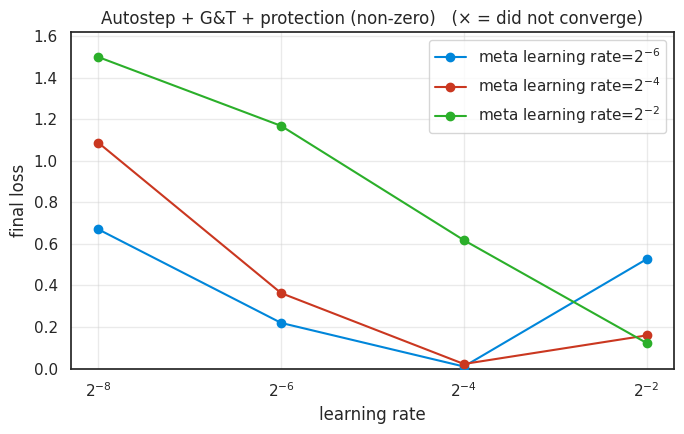

In [15]:
AUTOSTEP_NONZERO_GRID = {
    'learning_rate': [2.0 ** e for e in range(-8, -1, 2)],       # 2^-8 .. 2^-2
    'meta_learning_rate': [2.0 ** e for e in range(-6, -1, 2)],  # 2^-6 .. 2^-2
}
run_method_sweep(METHODS['autostep_nonzero'], AUTOSTEP_NONZERO_GRID, N_SWEEP_SEEDS)
cfgs, runs = load_sweep_data()
autostep_nonzero_summary = summarize_runs(cfgs, runs, 'autostep_nonzero', swept_vars(AUTOSTEP_NONZERO_GRID), FINAL_FRACTION, BASELINE_LOSS)
plot_sensitivity(autostep_nonzero_summary, swept_vars(AUTOSTEP_NONZERO_GRID), 'Autostep + G&T + protection (non-zero)')
plt.show()

### Non-zero-weight protection — best configuration learning curve (30 seeds)

[I 2026-07-26 14:43:30,967] Using an existing study with name 'feature_sifting_protection/autostep_nonzero_best' instead of creating a new one.
INFO:mlflow_sweeper.runner:Using existing parent MLflow run: 6f7f841381cd4ca0929c1c67d5b08147.


INFO:mlflow_sweeper.runner:Study is complete. No more trials to run.


Autostep + G&T + protection (non-zero) best: {'learning_rate': 0.0625, 'meta_learning_rate': 0.015625}
Reusing cached CSVs (138 runs, no new data to download).


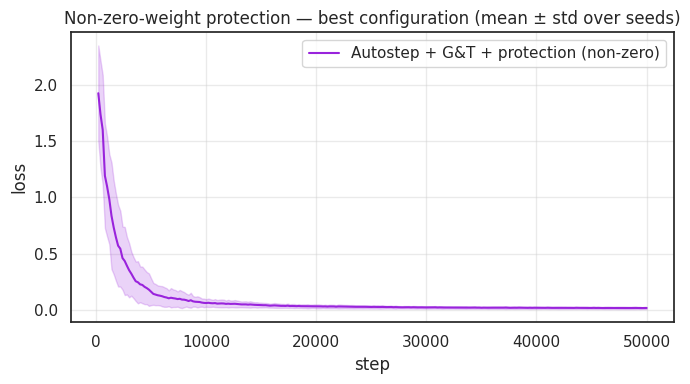

In [16]:
autostep_nonzero_best = best_hparams(cfgs, runs, METHODS['autostep_nonzero'], AUTOSTEP_NONZERO_GRID)
print('Autostep + G&T + protection (non-zero) best:', autostep_nonzero_best)
run_method_sweep(METHODS['autostep_nonzero'], autostep_nonzero_best, N_CURVE_SEEDS, sweep_name='autostep_nonzero_best')
cfgs, runs = load_sweep_data()

plt.figure(figsize=(7, 4))
plot_learning_curve(runs, 'autostep_nonzero_best', label='Autostep + G&T + protection (non-zero)',
                    color=get_color_palette(n=4)[3])
plt.title('Non-zero-weight protection — best configuration (mean ± std over seeds)')
plt.legend(); plt.tight_layout(); plt.show()

## 5. Autostep + G&T + step-size protection (windowed sign-flip)

A variant of the sign-flip test that no longer requires the two flips to land on the exact same step. A
feature is pruned when its Autostep gradient trace `h` and its weight both flip sign **within `1 / step-size`
steps of each other**, where `step-size` is the feature's own (adaptive) Autostep step-size — so the tolerated
window widens as a feature learns more slowly. The only extra state is a per-feature count of steps since `h`
last flipped and since the weight last flipped. Sweeps the initial step-size and the meta step-size.

In [17]:
K_V = 5.0  # v averages over ~K_V of the learner's own adaptation timescales (same k as any trace)


class AutostepSignFlipProtect(eqx.Module):
    """Autostep + G&T with noise-floor sign-flip pruning. For a dead feature, both the weight and
    the Autostep trace `h` are stationary with variance `step-size * E[delta^2] / 2` (the E[x^2]
    cancels), so that quantity is a per-feature "noise floor" derived entirely from the learned
    step-size and a global residual-power estimate `v`. A feature is pruned when its weight
    crosses zero while h^2 sits inside the floor -- the weight is at zero while h is
    statistically indistinguishable from noise. Detection power is uniform in step-size: a dead
    feature is pruned within ~1-2 of its own weight crossings at any alpha.

    Note: fresh features start at exactly (w=0, h=0), inside the floor by construction, so some
    useful newborns are pruned in their first few steps before h escapes the noise band (~30% at
    typical settings). This churn is accepted: culled useful features are simply regenerated,
    while dead features are culled in a handful of steps with no unprunable states."""
    optimizer: optax.GradientTransformation = eqx.field(static=True)
    w: jax.Array
    opt_state: optax.OptState
    v: jax.Array         # scalar EMA of delta^2 (global residual power)
    prune_mask: jax.Array

    @classmethod
    def init(cls, hparams, key):
        n = N_LEARNER_FEATURES
        optimizer = optax_idbd(init_lr=hparams['learning_rate'],
                               meta_lr=hparams['meta_learning_rate'], autostep=True)
        w = jnp.zeros((1, n))
        return cls(optimizer=optimizer, w=w, opt_state=optimizer.init(w),
                   v=jnp.asarray(0.0), prune_mask=jnp.zeros(n, dtype=bool))

    def step(self, x, y):
        loss, loss_grads = linear_loss_and_grads(self.w, x, y)
        w_prev = self.w
        updates, opt_state = self.optimizer.update((loss_grads, x[None, :]), self.opt_state, self.w)
        w_new = optax.apply_updates(self.w, updates)
        w_flip = (w_prev * w_new < 0.0)[0]
        
        step_size = jnp.exp(opt_state.beta)[0]
        effective_lr = jnp.sum(step_size * x ** 2)
        v = self.v + (effective_lr / K_V) * (loss - self.v)

        # Prune when the weight crosses zero while h is inside the per-feature noise floor.
        floor2 = step_size * v / 2.0                         # (n,)
        prune_mask = w_flip & (opt_state.h[0] ** 2 < floor2)

        w_new = jnp.where(prune_mask[None, :], 0.0, w_new)
        opt_state = reset_idbd_state(opt_state, prune_mask)

        return tree_replace(self, w=w_new, opt_state=opt_state, v=v, prune_mask=prune_mask), loss
    
    
AUTOSTEP_SIGNFLIP_DEFAULTS = {'learning_rate': 2.0 ** -2, 'meta_learning_rate': 2.0 ** -4}
METHODS['autostep_signflip'] = MethodSpec('autostep_signflip', 'Autostep + G&T + protection (sign-flip, simultaneous only)',
                                          AutostepSignFlipProtect, AUTOSTEP_SIGNFLIP_DEFAULTS)

INFO:mlflow_sweeper.runner:Deleted Optuna study: feature_sifting_protection/autostep_signflip.
INFO:mlflow_sweeper.runner:Deleted 13 associated MLflow runs (0 child runs).
[I 2026-07-26 14:43:31,677] A new study created in RDB with name: feature_sifting_protection/autostep_signflip
INFO:mlflow_sweeper.runner:Creating new parent MLflow run: autostep_signflip.
INFO:mlflow_sweeper.runner:Sweep run #0.
INFO:mlflow_sweeper.runner:Created trial MLflow run: f134e51dafba445681f04731bdc882bc.
INFO:mlflow_sweeper.runner:Running new trial: `__main__.make_objective.<locals>.objective(learning_rate=0.25, meta_learning_rate=0.015625, n_seeds=5)`
INFO:2026-07-26 14:43:32,471:jax._src.xla_bridge:752: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory

Reusing cached CSVs (138 runs, no new data to download).


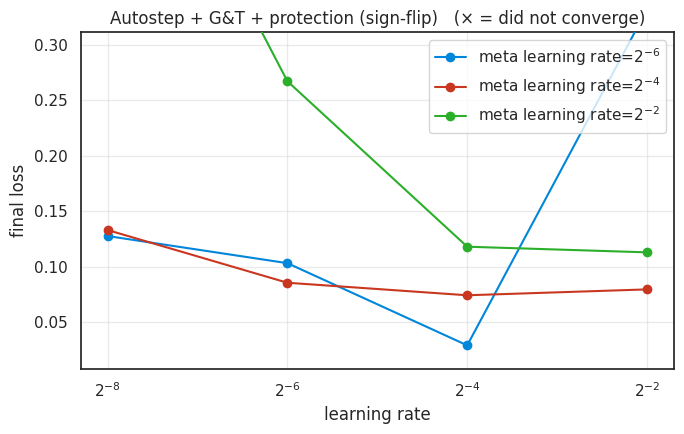

In [18]:
AUTOSTEP_SIGNFLIP_GRID = {
    'learning_rate': [2.0 ** e for e in range(-8, -1, 2)],       # 2^-8 .. 2^-2
    'meta_learning_rate': [2.0 ** e for e in range(-6, -1, 2)],  # 2^-6 .. 2^-2
}
run_method_sweep(METHODS['autostep_signflip'], AUTOSTEP_SIGNFLIP_GRID, N_SWEEP_SEEDS, overwrite=True)
cfgs, runs = load_sweep_data()
autostep_signflip_summary = summarize_runs(cfgs, runs, 'autostep_signflip', swept_vars(AUTOSTEP_SIGNFLIP_GRID), FINAL_FRACTION, BASELINE_LOSS)
plot_sensitivity(autostep_signflip_summary, swept_vars(AUTOSTEP_SIGNFLIP_GRID), 'Autostep + G&T + protection (sign-flip)')
plt.show()

### Sign-flip protection — best configuration learning curve (30 seeds)

[I 2026-07-26 14:44:18,544] Using an existing study with name 'feature_sifting_protection/autostep_signflip_best' instead of creating a new one.
INFO:mlflow_sweeper.runner:Using existing parent MLflow run: 88871ab34f4c4e8c8ce8e2d3926cd76f.
INFO:mlflow_sweeper.runner:Study is complete. No more trials to run.


Autostep + G&T + protection (sign-flip) best: {'learning_rate': 0.0625, 'meta_learning_rate': 0.015625}
Reusing cached CSVs (138 runs, no new data to download).


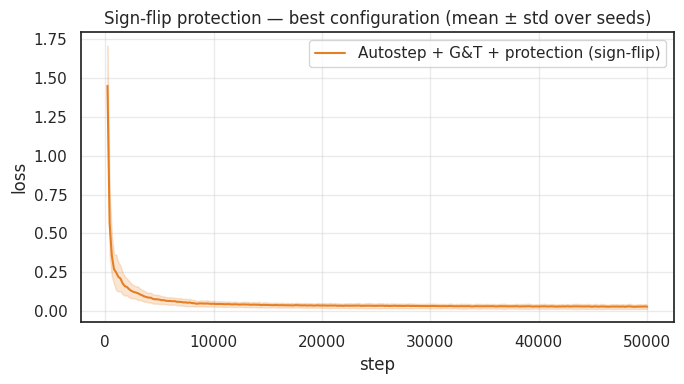

In [19]:
autostep_signflip_best = best_hparams(cfgs, runs, METHODS['autostep_signflip'], AUTOSTEP_SIGNFLIP_GRID)
print('Autostep + G&T + protection (sign-flip) best:', autostep_signflip_best)
run_method_sweep(METHODS['autostep_signflip'], autostep_signflip_best, N_CURVE_SEEDS, sweep_name='autostep_signflip_best')
cfgs, runs = load_sweep_data()

plt.figure(figsize=(7, 4))
plot_learning_curve(runs, 'autostep_signflip_best', label='Autostep + G&T + protection (sign-flip)',
                    color=get_color_palette(n=5)[4])
plt.title('Sign-flip protection — best configuration (mean ± std over seeds)')
plt.legend(); plt.tight_layout(); plt.show()

## All methods — best configurations

The best configuration of each method (already run above with 30 seeds) plotted together. Data is loaded from
the cache, so this cell does not re-run any experiment.

Reusing cached CSVs (138 runs, no new data to download).


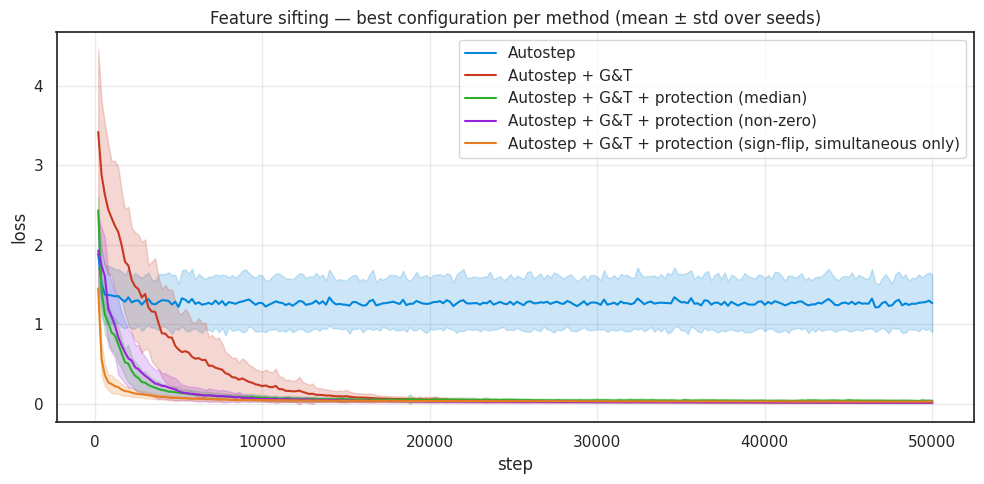

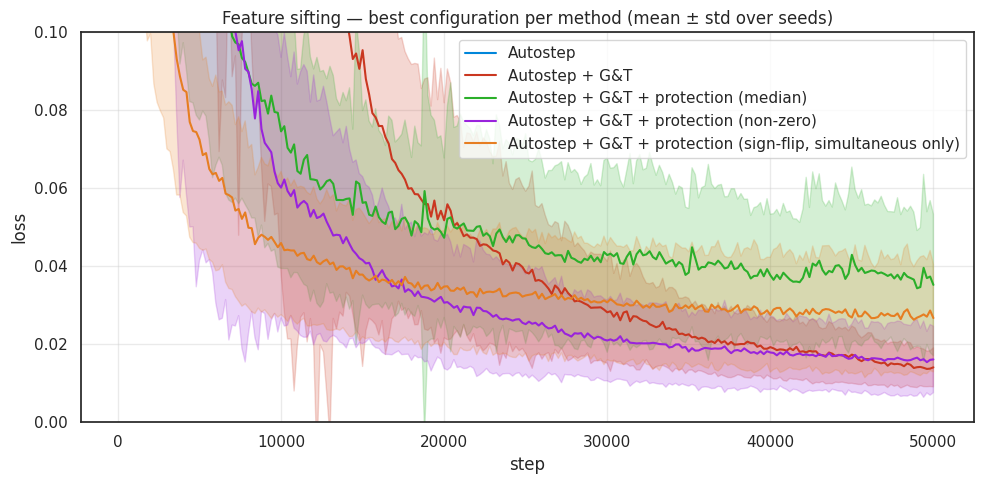

In [20]:
cfgs, runs = load_sweep_data()

best_sweeps = [(m.label, key + '_best') for key, m in METHODS.items()]
colors = get_color_palette(n=len(best_sweeps))

plt.figure(figsize=(10, 5))
ax = plt.gca()
for (label, sweep_name), color in zip(best_sweeps, colors):
    if sweep_name in runs:
        plot_learning_curve(runs, sweep_name, label=label, color=color, ax=ax)
ax.set_title('Feature sifting — best configuration per method (mean ± std over seeds)')
ax.legend()
plt.tight_layout(); plt.show()


plt.figure(figsize=(10, 5))
ax = plt.gca()
for (label, sweep_name), color in zip(best_sweeps, colors):
    if sweep_name in runs:
        plot_learning_curve(runs, sweep_name, label=label, color=color, ax=ax)
ax.set_title('Feature sifting — best configuration per method (mean ± std over seeds)')
ax.legend()
plt.ylim(0.0, 0.1)
plt.tight_layout(); plt.show()

## Loss floor and pruning rate

Two per-method diagnostics that the sweeps do **not** log (only `loss` is logged). We replay each method's
*best* configuration in-memory over the same 30 seeds and record, at every step:

* the **loss floor** — for each of the 10 unique target features, the lowest noise coefficient among the
  candidate slots currently pointing at it (`1.0` for an uncovered target), summed. It measures the quality
  of the feature set a method has assembled: a good sifter keeps low-noise candidates and drives the floor
  down, while plain Autostep (no pruning) stays at the fixed floor of its initial random features. (This is a
  feature-quality floor in units of summed noise coefficient, not a squared-error lower bound, so it is shown
  on its own axis rather than under the loss curves.)
* the **pruning rate** — the number of candidate slots regenerated per step (log scale; a method that never
  prunes is flagged in the legend).

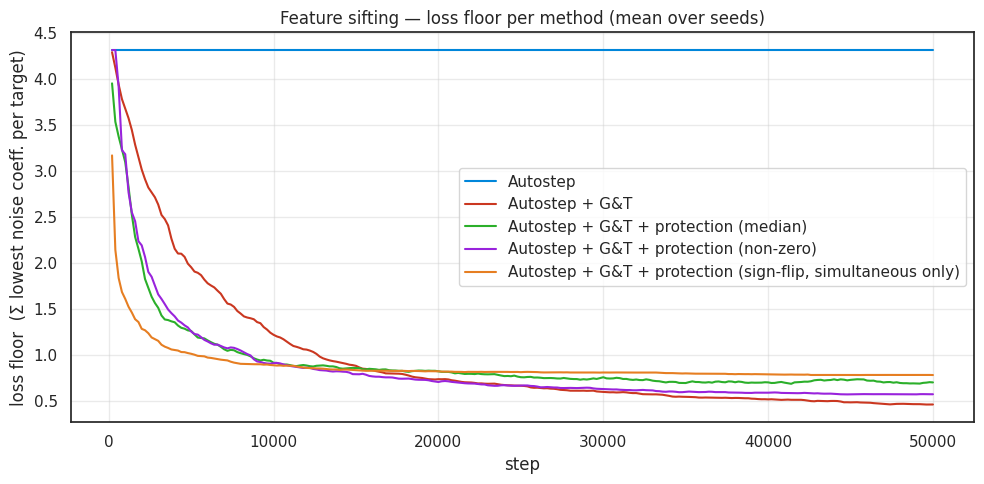

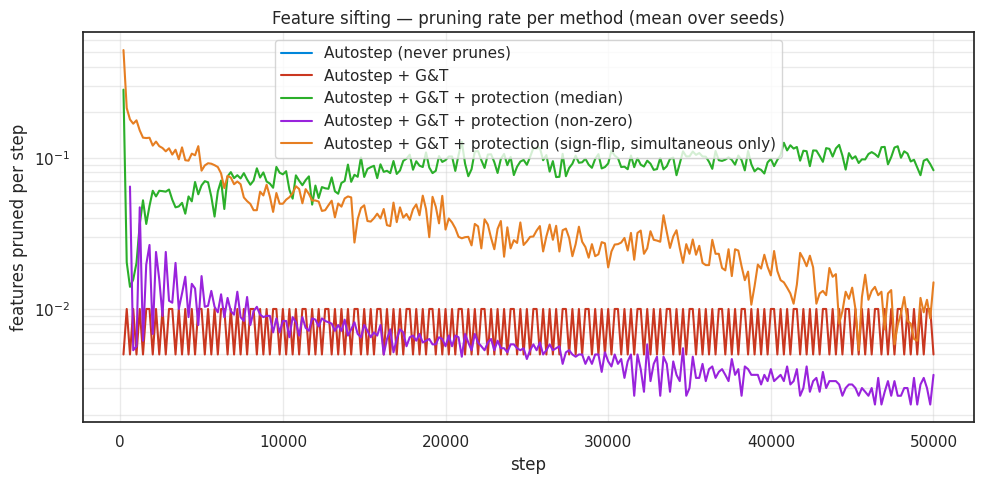

In [21]:
# Replay each method's best config in-memory, tracking the loss floor and pruning rate (neither is
# logged during the sweeps). Same hyperparameters / seeds / steps as the logged best-config curves,
# so these diagnostics correspond exactly to the loss curves plotted above.

def best_config_hparams(spec):
    """Best hyperparameters of `<name>_best`, read back from the cached sweep params (swept values
    overriding the method's non-swept defaults)."""
    if spec.name + '_best' not in cfgs:
        return dict(spec.defaults)
    row = cfgs[spec.name + '_best'].iloc[0]
    swept = {}
    for k in spec.defaults:
        if k in row.index:
            try:
                v = float(row[k])
            except (TypeError, ValueError):
                continue
            if np.isfinite(v):
                swept[k] = v
    return {**spec.defaults, **swept}


def run_with_diagnostics(method_cls, hparams, n_seeds):
    """Like `run_all_seeds`, but each step also emits the loss floor and the prune count."""
    def run_one_seed(seed_key):
        task_key, init_key = jax.random.split(seed_key)
        task = FeatureSiftingTask(N_TARGET_FEATURES, N_LEARNER_FEATURES, TARGET_NOISE_STD, key=task_key)
        state = method_cls.init(hparams, init_key)

        def scan_step(carry, _):
            task, state = carry
            task, (x, y) = task.step(state.prune_mask)
            state, _ = state.step(x, jnp.squeeze(y))
            return (task, state), (noise_floor(task), jnp.sum(state.prune_mask))

        _, out = jax.lax.scan(scan_step, (task, state), length=NUM_STEPS)
        return out   # (floor, n_pruned), each (NUM_STEPS,)

    seed_keys = jax.random.split(jax.random.PRNGKey(BASE_SEED), n_seeds)
    return jax.jit(jax.vmap(run_one_seed))(seed_keys)


def bin_over_seeds(arr, n_points=N_LOG_POINTS):
    """Bin (n_seeds, n_steps) into (n_points,) window-means, then mean over seeds — matching the
    binning `log_run` applies to the logged loss curve, so the x-axes line up."""
    arr = np.asarray(arr)
    n_seeds, n_steps = arr.shape
    w = n_steps // n_points
    binned = arr[:, :w * n_points].reshape(n_seeds, n_points, w).mean(axis=2)
    return np.arange(1, n_points + 1) * w, binned.mean(axis=0)


diagnostics = {}
for key, spec in METHODS.items():
    floor, n_pruned = run_with_diagnostics(spec.cls, best_config_hparams(spec), N_CURVE_SEEDS)
    steps, floor_curve = bin_over_seeds(floor)
    _, prune_curve = bin_over_seeds(n_pruned)
    diagnostics[key] = {'steps': steps, 'floor': floor_curve, 'prune_rate': prune_curve}

colors = get_color_palette(n=len(METHODS))   # same order/palette as the loss comparison above

# --- Loss floor per method ---
plt.figure(figsize=(10, 5))
ax = plt.gca()
for (key, spec), color in zip(METHODS.items(), colors):
    d = diagnostics[key]
    ax.plot(d['steps'], d['floor'], color=color, label=spec.label)
ax.set_xlabel('step'); ax.set_ylabel('loss floor  (Σ lowest noise coeff. per target)')
ax.set_title('Feature sifting — loss floor per method (mean over seeds)')
ax.grid(True, alpha=0.4); ax.legend()
plt.tight_layout(); plt.show()

# --- Pruning rate per method (log scale; never-pruning methods flagged in the legend) ---
plt.figure(figsize=(10, 5))
ax = plt.gca()
for (key, spec), color in zip(METHODS.items(), colors):
    d = diagnostics[key]
    if np.any(d['prune_rate'] > 0):
        ax.plot(d['steps'], np.where(d['prune_rate'] > 0, d['prune_rate'], np.nan),
                color=color, label=spec.label)
    else:
        ax.plot([], [], color=color, label=f'{spec.label} (never prunes)')
ax.set_yscale('log')
ax.set_xlabel('step'); ax.set_ylabel('features pruned per step')
ax.set_title('Feature sifting — pruning rate per method (mean over seeds)')
ax.grid(True, alpha=0.4, which='both'); ax.legend()
plt.tight_layout(); plt.show()